# El eléctrico que encaja en tu vida
## 36 modelos, distintas vidas · Nebula

No compramos kilómetros de catálogo: compramos una forma de movernos. ¿Buscas gastar poco, llevar un carrito, escaparte en pareja o disfrutar de tecnología que de verdad ayuda?

Este análisis compara **36 modelos distintos**, con **una sola versión de referencia por modelo**. Incluye BYD, MG, Leapmotor, XPENG, Omoda, Jaecoo, Changan/Deepal y GAC. MG se identifica como marca de origen británico perteneciente a un grupo chino; esa agrupación no indica dónde se fabrica cada coche.

**España · consulta: 3 de octubre de 2026.** Es una muestra editorial, no un censo completo. Los vacíos se muestran: no se inventan cifras ni se convierten en ceros.

## 1. Preparación del análisis

La misma estructura sencilla de los anteriores: datos, una pregunta, un gráfico y una lectura fácil de comprender. Ejecuta todas las celdas en orden; no necesita internet.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import unicodedata

# trabajo con los archivos de esta carpeta
BASE = Path.cwd()
if not (BASE / "electricos_comparativa.csv").exists():
    BASE = Path(r"C:\Users\rober\OneDrive\Documentos\proyectos_datos\_repos_nebula\electricos_analisis")
GRAFICOS = BASE / "graficos"
RESULTADOS = BASE / "resultados"
GRAFICOS.mkdir(exist_ok=True)
RESULTADOS.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 120})
MORADO, AZUL, GRIS = "#7655B5", "#243F67", "#8C93A4"
pd.set_option("display.max_rows", 50)
pd.set_option("display.max_colwidth", 65)

def guardar(nombre):
    plt.tight_layout()
    plt.savefig(GRAFICOS / nombre, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()


## 2. Carga del dataset

Una fila equivale a un modelo, no a un acabado. La versión seleccionada permite vincular sus cifras sin combinar la batería barata con la autonomía del acabado más caro.

In [2]:
df = pd.read_csv(BASE / "electricos_comparativa.csv")
fuentes = pd.read_csv(BASE / "fuentes.csv")
numericas = ["precio_base_eur", "precio_publicado_eur", "autonomia_wltp_km",
             "plazas", "longitud_mm", "maletero_declarado_l",
             "maletero_vda_l", "carga_10_80_min"]
df[numericas] = df[numericas].apply(pd.to_numeric, errors="raise")
display(df[["modelo", "version", "precio_base_eur", "autonomia_wltp_km", "estado_precio"]])


,modelo,version,precio_base_eur,autonomia_wltp_km,estado_precio
0,Dacia Spring,Expression Electric70 MY26,NaN,225.0,pendiente
1,BYD Dolphin Surf,Active MY26 4plazas,20140.0,220.0,tarifa
2,Hyundai INSTER,MAXX42 kWh,26840.0,327.0,referencia
3,Renault 5 E-Tech,Evolution40 kWh120CV,28085.0,315.0,tarifa
4,Citroën ë-C3,YOU Urban Range30 kWh,NaN,212.0,pendiente
5,Kia EV3,Air58.3 kWh MY25,NaN,436.0,pendiente
6,Škoda Elroq,50 52 kWh útiles,NaN,375.0,pendiente
7,Tesla Model 3,Tracción trasera,36990.0,572.0,tarifa
8,BYD Dolphin,Comfort,36690.0,427.0,tarifa
9,BYD Atto 2,Comfort,36200.0,430.0,tarifa


## 3. Primera inspección: ¿cuántos coches estamos comparando?

La comprobación de duplicados es obligatoria. No añadimos Surf Active, Boost y Comfort como tres coches; tampoco contamos Atto 3 y Atto 3 EVO por separado.

In [3]:
def normalizar(texto):
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode()
    return "".join(c for c in texto.lower() if c.isalnum())

assert len(df) >= 30, "La muestra debe tener al menos 30 modelos."
assert df["modelo"].map(normalizar).is_unique, "Hay modelos duplicados."
assert df["propulsion"].eq("BEV").all(), "No mezclar BEV con PHEV o REEV."
ids_fuentes = set(fuentes["id"])
assert all(set(ids.split(";")).issubset(ids_fuentes) for ids in df["fuentes"])
assert (df[numericas].stack().dropna() > 0).all(), "No usar ceros como datos ausentes."

display(pd.DataFrame({
    "Comprobación": ["Modelos distintos", "Marcas", "Marcas chinas o de grupo chino",
                     "Tarifas documentadas", "Autonomías combinadas documentadas"],
    "Resultado": [df["modelo"].nunique(), df["marca"].nunique(),
                  df.loc[df["grupo"].eq("Marca china o grupo chino"), "marca"].nunique(),
                  df["precio_base_eur"].notna().sum(), df["autonomia_wltp_km"].notna().sum()]
}))
display(df[numericas].notna().sum().rename("Datos disponibles").to_frame())
display(df.loc[df["precio_base_eur"].isna(),
               ["modelo", "estado_precio", "precio_publicado_eur", "nota"]])


,Comprobación,Resultado
0,Modelos distintos,36
1,Marcas,20
2,Marcas chinas o de grupo chino,8
3,Tarifas documentadas,23
4,Autonomías combinadas documentadas,33


,Datos disponibles
precio_base_eur,23
precio_publicado_eur,4
autonomia_wltp_km,33
plazas,36
longitud_mm,16
maletero_declarado_l,17
maletero_vda_l,2
carga_10_80_min,5


,modelo,estado_precio,precio_publicado_eur,nota
0,Dacia Spring,pendiente,16245.0,Precio anunciado16245 con condiciones; no tarifa limpia.
4,Citroën ë-C3,pendiente,21400.0,Contado21400 válido hasta30/09; vencido.
5,Kia EV3,pendiente,NaN,Catálogo MY25; precio y disponibilidad del acabado por confir...
6,Škoda Elroq,pendiente,NaN,Referencia catálogo anterior; no mezclar con nuevo Urban61.
15,Leapmotor T03,pendiente,NaN,Tarifa española sin ayudas pendiente; no usar tarifa europea ...
16,Leapmotor B10,pendiente,NaN,No es REEV. Tarifa española limpia pendiente.
17,Leapmotor C10,pendiente,NaN,"Solo BEV, excluida versión REEV. Referencia2024: contrastar M..."
20,Omoda 5 EV,pendiente,NaN,Carga30-80 en28min: excluida gráfico10-80.
27,Renault Scenic E-Tech,pendiente,41970.0,"Contado41970 promoción septiembre vencida, no tarifa."
30,Volkswagen ID.3,pendiente,NaN,Neo y antiguo ID.3 cuentan como un único modelo.


### Cómo leer los datos

Hay 36 modelos y 23 tarifas documentadas. **No todos tienen una tarifa actual comprobada**. Las referencias de 2025 se muestran aparte; no son ofertas vigentes. El configurador de Tesla Model Y no permitió recuperar una ficha reproducible: su fila permanece visible, pero no entra en rankings numéricos.

WLTP significa autonomía homologada de ciclo combinado, generalmente el máximo publicado para la versión elegida: no autonomía real en autopista. Los dos GAC usan ficha técnica europea y tarifa española; hasta confirmar la unidad española, se excluyen del cruce precio/autonomía. Una ausencia significa «no verificado», no «no disponible» ni «cero».

## 4. ¿Cuáles son más asequibles?

Comparamos tarifas sin subvención ni descuento por financiación. El precio promocional se conserva en otra columna, pero nunca sustituye al PVP. La división por fecha evita presentar una tarifa antigua como una ganga actual.

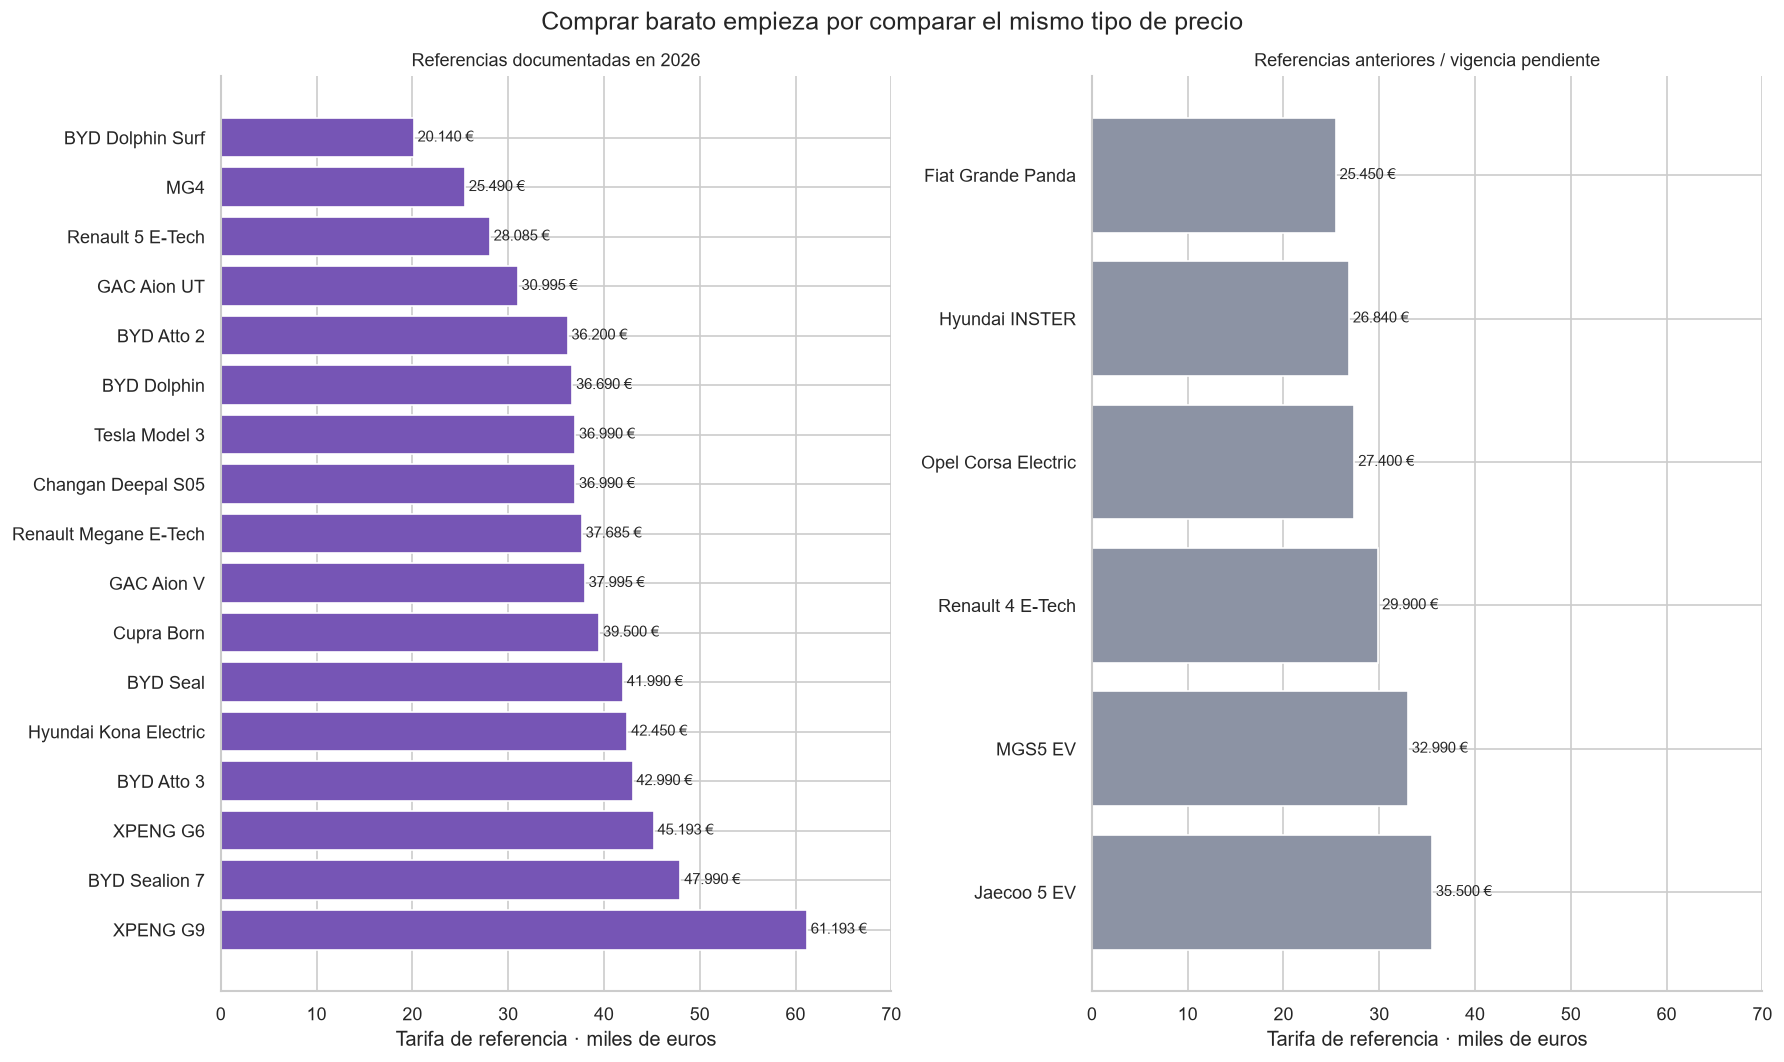

,modelo,version,precio_base_eur,fecha_tarifa,bloque_precio
28,Fiat Grande Panda,RED eléctrico44 kWh,25450.0,2025-02,Referencias anteriores / vigencia pendiente
2,Hyundai INSTER,MAXX42 kWh,26840.0,2026-08,Referencias anteriores / vigencia pendiente
35,Opel Corsa Electric,Edition51 kWh156CV,27400.0,2025-03-24,Referencias anteriores / vigencia pendiente
25,Renault 4 E-Tech,Evolution40 kWh,29900.0,2025-03-04,Referencias anteriores / vigencia pendiente
14,MGS5 EV,Confort49 kWh,32990.0,2025-05-09,Referencias anteriores / vigencia pendiente
21,Jaecoo 5 EV,Pure60.9 kWh,35500.0,2025,Referencias anteriores / vigencia pendiente
1,BYD Dolphin Surf,Active MY26 4plazas,20140.0,2026-09,Referencias documentadas en 2026
13,MG4,Urban Comfort43 kWh,25490.0,2026-04-28,Referencias documentadas en 2026
3,Renault 5 E-Tech,Evolution40 kWh120CV,28085.0,2026-10-01,Referencias documentadas en 2026
23,GAC Aion UT,Premium europeo,30995.0,2026-10-03,Referencias documentadas en 2026


In [4]:
tarifas = df.dropna(subset=["precio_base_eur"]).copy()
tarifas["bloque_precio"] = tarifas["estado_precio"].map(
    {"tarifa": "Referencias documentadas en 2026", "referencia": "Referencias anteriores / vigencia pendiente"})
tarifas.to_csv(RESULTADOS / "tarifas_comparables.csv", index=False, encoding="utf-8-sig")
fig, axes = plt.subplots(1, 2, figsize=(15, 9), sharex=True)
for ax, (bloque, color) in zip(axes, [
    ("Referencias documentadas en 2026", MORADO),
    ("Referencias anteriores / vigencia pendiente", GRIS)]):
    datos = tarifas[tarifas["bloque_precio"].eq(bloque)].sort_values("precio_base_eur", ascending=False)
    ax.barh(datos["modelo"], datos["precio_base_eur"] / 1000, color=color)
    for i, precio in enumerate(datos["precio_base_eur"]):
        ax.text(precio / 1000 + .4, i, f"{precio:,.0f} €".replace(",", "."), va="center", fontsize=9)
    ax.set_title(bloque, fontsize=11)
    ax.set_xlabel("Tarifa de referencia · miles de euros")
    ax.set_xlim(0, 70)
fig.suptitle("Comprar barato empieza por comparar el mismo tipo de precio", fontsize=15)
guardar("01_precios.png")
display(tarifas.sort_values(["bloque_precio", "precio_base_eur"])[
    ["modelo", "version", "precio_base_eur", "fecha_tarifa", "bloque_precio"]])


### Lectura Nebula

Entre las tarifas de 2026 documentadas, Dolphin Surf Active representa la puerta de entrada, pero ofrece cuatro plazas y 220 km WLTP. MG4 Urban Comfort añade cinco plazas y 325 km por un desembolso mayor. **Menor precio y mayor utilidad no siempre son la misma compra.**

Spring y T03 merecen estar en la selección urbana, pero no se les adjudica un puesto económico con una oferta que depende de ayudas. Antes de publicar «el más barato de España», hay que confirmar sus tarifas sin condiciones.

## 5. ¿Qué modelos encajan en una familia?

Primera criba editable: cinco plazas, al menos 300 km WLTP y 400 litros declarados atrás. Sirve para buscar candidatos, no para certificar que caben tres sillitas. No sumamos el maletero delantero ni el volumen con los asientos abatidos.

,modelo,version,autonomia_wltp_km,maletero_declarado_l,metodo_maletero,precio_base_eur
7,Tesla Model 3,Tracción trasera,572.0,594.0,declarado; método no armonizado,36990.0
26,Renault Megane E-Tech,Techno67 kWh220CV,500.0,440.0,VDA,37685.0
22,Changan Deepal S05,Pro BEV68.8 kWh,485.0,492.0,declarado; método no armonizado,36990.0
12,BYD Sealion 7,Comfort,482.0,520.0,declarado; método no armonizado,47990.0
11,BYD Seal,Comfort actualizado,460.0,485.0,declarado; método no armonizado,41990.0
5,Kia EV3,Air58.3 kWh MY25,436.0,460.0,declarado; método no armonizado,NaN
20,Omoda 5 EV,Pure61 kWh,430.0,442.0,declarado; método no armonizado,NaN
21,Jaecoo 5 EV,Pure60.9 kWh,402.0,480.0,declarado; método no armonizado,35500.0
6,Škoda Elroq,50 52 kWh útiles,375.0,470.0,declarado; método no armonizado,NaN
14,MGS5 EV,Confort49 kWh,340.0,453.0,declarado; método no armonizado,32990.0


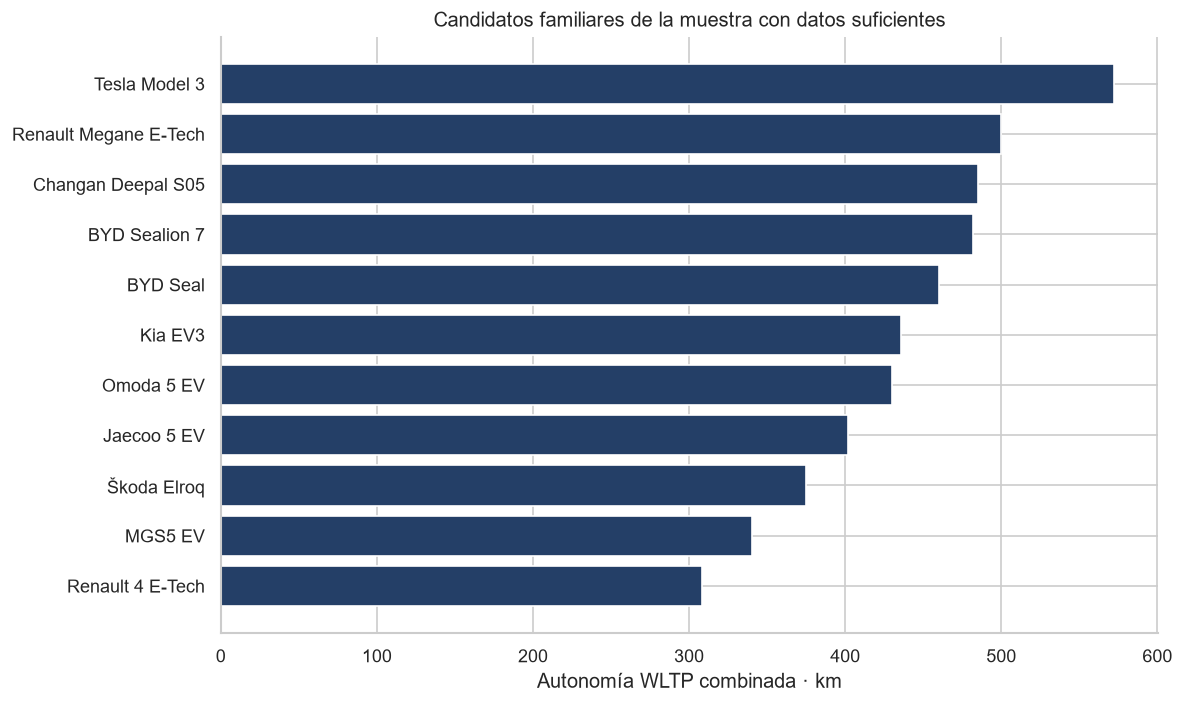

In [5]:
MIN_KM_FAMILIA = 300
MIN_LITROS_FAMILIA = 400
familia = df[(df["plazas"] >= 5) &
             (df["autonomia_wltp_km"] >= MIN_KM_FAMILIA) &
             (df["maletero_declarado_l"] >= MIN_LITROS_FAMILIA)].copy()
familia = familia.sort_values("autonomia_wltp_km", ascending=False)
familia.to_csv(RESULTADOS / "candidatos_familia.csv", index=False, encoding="utf-8-sig")
display(familia[["modelo", "version", "autonomia_wltp_km",
                "maletero_declarado_l", "metodo_maletero", "precio_base_eur"]])
# no ordeno maleteros de métodos distintos como si fueran equivalentes
plt.figure(figsize=(10, 6))
plt.barh(familia["modelo"].iloc[::-1], familia["autonomia_wltp_km"].iloc[::-1], color=AZUL)
plt.xlabel("Autonomía WLTP combinada · km")
plt.title("Candidatos familiares de la muestra con datos suficientes")
guardar("05_familia.png")


### Lectura Nebula

Deepal S05, Jaecoo 5 EV y MGS5 EV amplían la conversación familiar junto con EV3, Elroq, Megane y Sealion 7. Model 3 también pasa la criba numérica, pero su acceso al maletero es de berlina: no es equivalente a un portón.

**No aparecer aquí no significa ser peor para una familia.** MG4 Urban declara más de 500 litros, pero falta una medida exacta armonizada; GAC Aion V y Scenic tienen argumentos familiares, aunque esta tabla requiere datos de maletero que no hemos cerrado. El siguiente paso práctico es probar carrito, sillitas, puertas, asiento central y carga útil.

## 6. Para parejas sin hijos: ¿menos coche puede ser suficiente?

No suponemos que una pareja siempre quiera un coche pequeño. Esta criba describe un uso concreto: ciudad y escapadas, longitud hasta 4,40 m y al menos 250 km WLTP. Para quien viaje mucho, conviene mirar también las berlinas y SUV más grandes.

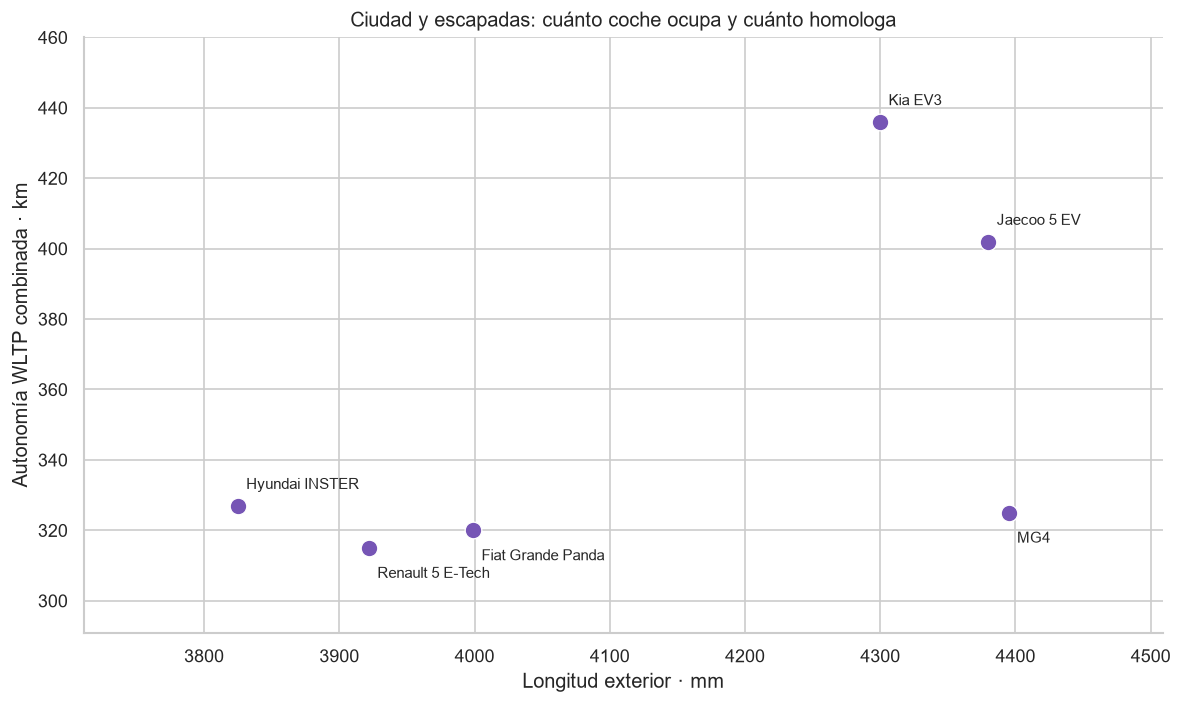

,modelo,version,longitud_mm,autonomia_wltp_km,plazas
2,Hyundai INSTER,MAXX42 kWh,3825.0,327.0,4
3,Renault 5 E-Tech,Evolution40 kWh120CV,3922.0,315.0,5
5,Kia EV3,Air58.3 kWh MY25,4300.0,436.0,5
13,MG4,Urban Comfort43 kWh,4395.0,325.0,5
21,Jaecoo 5 EV,Pure60.9 kWh,4380.0,402.0,5
28,Fiat Grande Panda,RED eléctrico44 kWh,3999.0,320.0,5


In [6]:
MAX_LONGITUD_PAREJA = 4400
MIN_KM_PAREJA = 250
parejas = df[(df["longitud_mm"] <= MAX_LONGITUD_PAREJA) &
             (df["autonomia_wltp_km"] >= MIN_KM_PAREJA)].copy()
parejas.to_csv(RESULTADOS / "candidatos_parejas.csv", index=False, encoding="utf-8-sig")
plt.figure(figsize=(10, 6))
sns.scatterplot(data=parejas, x="longitud_mm", y="autonomia_wltp_km", s=100, color=MORADO)
for i, (_, fila) in enumerate(parejas.iterrows()):
    plt.annotate(fila["modelo"], (fila["longitud_mm"], fila["autonomia_wltp_km"]),
                 xytext=(5, 10 if i % 2 == 0 else -18), textcoords="offset points", fontsize=9)
plt.xlabel("Longitud exterior · mm")
plt.ylabel("Autonomía WLTP combinada · km")
plt.title("Ciudad y escapadas: cuánto coche ocupa y cuánto homologa")
plt.margins(.2)
guardar("02_parejas.png")
display(parejas[["modelo", "version", "longitud_mm", "autonomia_wltp_km", "plazas"]])


### Lectura Nebula

INSTER y Renault 5 muestran dos formas de resolver una vida urbana; el primero tiene cuatro plazas, el segundo cinco. Grande Panda y MG4 Urban añaden espacio sin saltar a un SUV grande. Una pareja que hace muchos kilómetros puede preferir Model 3, Seal o un coche con más batería: la situación familiar no decide por sí sola la compra.

## 7. Relación calidad-precio: ¿cuánta autonomía compras?

No medimos calidad con un número inventado. Usamos una relación sencilla: **km WLTP por cada 1.000 € de tarifa**. Es una pista económica, no una valoración de confort, fiabilidad, seguridad o servicio posventa.

En el ranking principal solo entran tarifas de 2026 y una autonomía vinculada a España. Las referencias antiguas quedan visibles en la tabla exportada, pero fuera del gráfico.

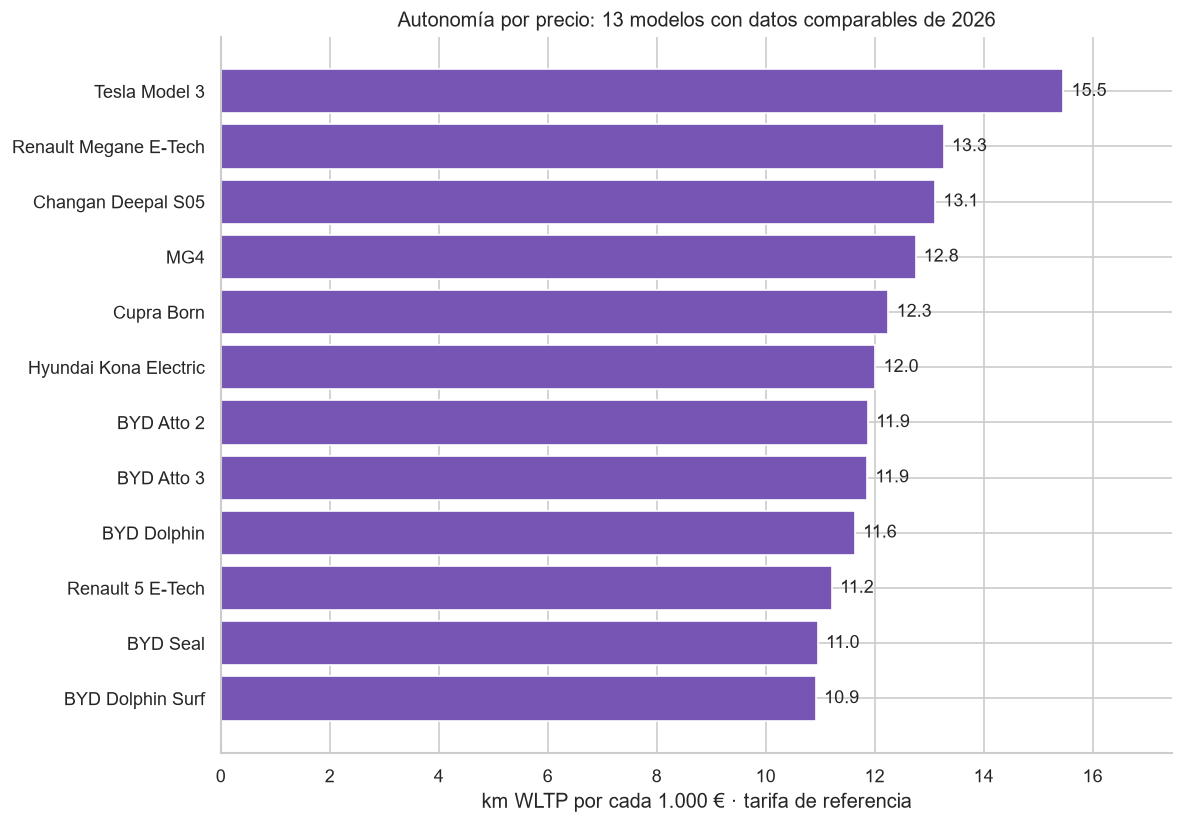

,modelo,precio_base_eur,autonomia_wltp_km,km_por_1000_eur,fecha_tarifa,estado_precio
35,Opel Corsa Electric,27400.0,429.0,15.66,2025-03-24,referencia
7,Tesla Model 3,36990.0,572.0,15.46,2026-10-03,tarifa
26,Renault Megane E-Tech,37685.0,500.0,13.27,2026-10-01,tarifa
22,Changan Deepal S05,36990.0,485.0,13.11,2026-09,tarifa
13,MG4,25490.0,325.0,12.75,2026-04-28,tarifa
28,Fiat Grande Panda,25450.0,320.0,12.57,2025-02,referencia
31,Cupra Born,39500.0,484.0,12.25,2026-04-07,tarifa
2,Hyundai INSTER,26840.0,327.0,12.18,2026-08,referencia
29,Hyundai Kona Electric,42450.0,510.0,12.01,2026-10-03,tarifa
9,BYD Atto 2,36200.0,430.0,11.88,2026-08,tarifa


In [7]:
valor = tarifas.dropna(subset=["autonomia_wltp_km"]).copy()
valor = valor[valor["alcance_tecnico"].eq("España")]
valor["km_por_1000_eur"] = valor["autonomia_wltp_km"] / valor["precio_base_eur"] * 1000
valor = valor.sort_values("km_por_1000_eur", ascending=False)
valor.to_csv(RESULTADOS / "autonomia_por_precio.csv", index=False, encoding="utf-8-sig")
valor_actual = valor[valor["estado_precio"].eq("tarifa")]
fig, ax = plt.subplots(figsize=(10, 7))
datos = valor_actual.sort_values("km_por_1000_eur").tail(12)
ax.barh(datos["modelo"], datos["km_por_1000_eur"], color=MORADO)
ax.set_xlabel("km WLTP por cada 1.000 € · tarifa de referencia")
ax.set_title(f"Autonomía por precio: {len(valor_actual)} modelos con datos comparables de 2026")
for i, numero in enumerate(datos["km_por_1000_eur"]):
    ax.text(numero + .15, i, f"{numero:.1f}", va="center")
ax.set_xlim(0, datos["km_por_1000_eur"].max() + 2)
guardar("03_autonomia_por_precio.png")
display(valor[["modelo", "precio_base_eur", "autonomia_wltp_km",
               "km_por_1000_eur", "fecha_tarifa", "estado_precio"]].round(2))


### Lectura Nebula

Esta relación permite comprobar si subir de presupuesto aporta autonomía proporcional. No permite decir «este es el mejor coche»: una pantalla fácil de usar, un taller próximo o una buena plaza trasera pueden valer más que unos kilómetros adicionales.

El indicador tampoco es coste total de propiedad: faltan seguro, financiación, depreciación, neumáticos y coste de recarga.

## 8. Tecnología: lo útil importa más que el tamaño de la pantalla

Comparamos funciones documentadas, no promesas de conducción autónoma ni un ranking subjetivo. Los asistentes requieren supervisión; algunos equipamientos cambian por acabado o son opcionales.

In [8]:
tecnologia = pd.DataFrame([
    ["Changan Deepal S05", "Pro BEV", "OTA, app, navegación, CarPlay/Android Auto, V2L6kW", "Conectividad y energía exterior", "HUD solo Max", "C01"],
    ["Renault Megane E-Tech", "Techno67", "Google integrado, planificador, preacondicionamiento", "Viajes y carga más sencillos", "Cámara360 y ayudas ampliadas son paquete opcional", "R02"],
    ["MG4", "Urban Comfort43", "App iSmart, navegación, CarPlay/Android Auto inalámbricos", "Conectividad desde acceso", "No valorar fluidez sin probarlo", "M01"],
    ["Jaecoo 5 EV", "Pure", "OTA, app, navegación conectada y V2L", "Control remoto y usos al aire libre", "Verificar funciones activas y servicios del acabado", "J01;J02"],
    ["GAC Aion UT", "Premium", "App, voz y V2L", "Gestión remota y energía exterior", "Confirmar ficha española y servicios", "G01"],
    ["GAC Aion V", "Premium", "App, voz y V2L", "Preparar habitáculo y controlar carga", "No atribuir extras de imágenes a todos los acabados", "G02"],
    ["Tesla Model 3", "Tracción trasera", "Planificador y gestión de Supercargadores", "Ruta y recarga integradas", "No implica conducción autónoma; comprobar servicios", "S17"],
    ["Cupra Born", "Born+58", "Equipamiento ampliable por packs", "Elegir funciones que realmente se usen", "HUD, cámara360 y V2L de packs no incluidos aquí", "U01"]
], columns=["modelo", "version", "funciones_documentadas", "utilidad", "matiz", "fuentes"])
assert set(tecnologia["modelo"]).issubset(set(df["modelo"]))
tecnologia.to_csv(RESULTADOS / "tecnologia_util.csv", index=False, encoding="utf-8-sig")
display(tecnologia)


,modelo,version,funciones_documentadas,utilidad,matiz,fuentes
0,Changan Deepal S05,Pro BEV,"OTA, app, navegación, CarPlay/Android Auto, V2L6kW",Conectividad y energía exterior,HUD solo Max,C01
1,Renault Megane E-Tech,Techno67,"Google integrado, planificador, preacondicionamiento",Viajes y carga más sencillos,Cámara360 y ayudas ampliadas son paquete opcional,R02
2,MG4,Urban Comfort43,"App iSmart, navegación, CarPlay/Android Auto inalámbricos",Conectividad desde acceso,No valorar fluidez sin probarlo,M01
3,Jaecoo 5 EV,Pure,"OTA, app, navegación conectada y V2L",Control remoto y usos al aire libre,Verificar funciones activas y servicios del acabado,J01;J02
4,GAC Aion UT,Premium,"App, voz y V2L",Gestión remota y energía exterior,Confirmar ficha española y servicios,G01
5,GAC Aion V,Premium,"App, voz y V2L",Preparar habitáculo y controlar carga,No atribuir extras de imágenes a todos los acabados,G02
6,Tesla Model 3,Tracción trasera,Planificador y gestión de Supercargadores,Ruta y recarga integradas,No implica conducción autónoma; comprobar servicios,S17
7,Cupra Born,Born+58,Equipamiento ampliable por packs,Elegir funciones que realmente se usen,"HUD, cámara360 y V2L de packs no incluidos aquí",U01


### Lectura Nebula

Hay varias respuestas a «mejor tecnología»: navegación y carga para viajar, compatibilidad con tu móvil o V2L para una escapada. Megane destaca por integración de servicios para viajes; Deepal por funciones documentadas de serie. Eso no demuestra que sean los más fluidos o fiables: esa parte exige una prueba, no una ficha comercial.

## 9. Viajar: la pausa también cuenta

Solo comparamos tiempos publicados del **10 al 80 %**. El 30–80 % de Omoda, Jaecoo y Deepal, o el 15–80 % del nuevo Megane, no se transforma en 10–80 % mediante una regla de tres: la curva de carga no es lineal.

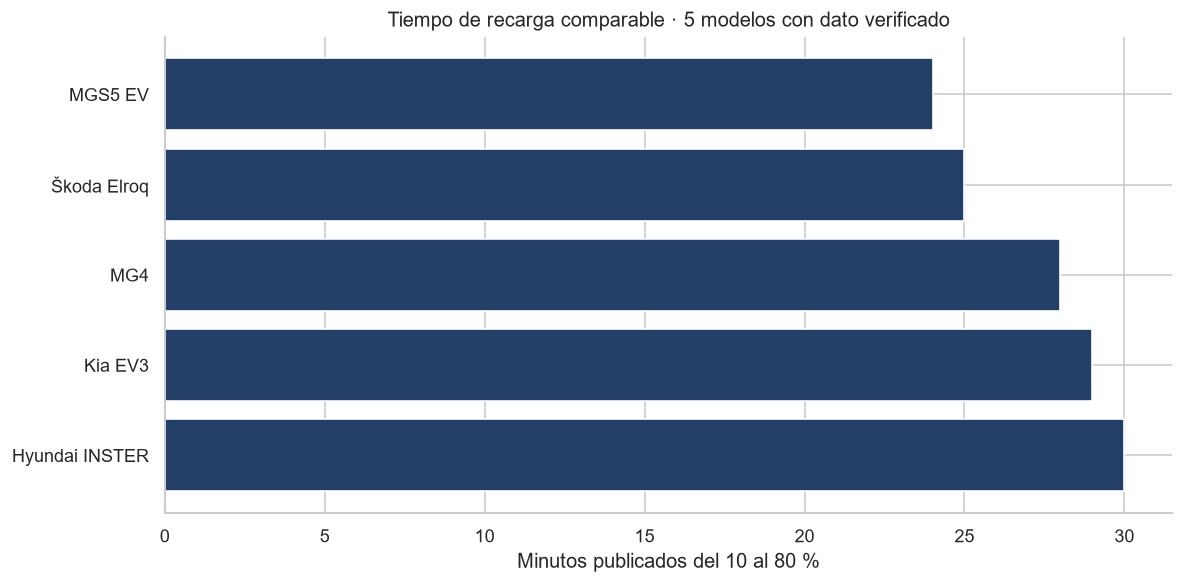

,modelo,version,carga_10_80_min,fuentes
2,Hyundai INSTER,MAXX42 kWh,30.0,S06;S07
5,Kia EV3,Air58.3 kWh MY25,29.0,S13
13,MG4,Urban Comfort43 kWh,28.0,M01
6,Škoda Elroq,50 52 kWh útiles,25.0,S14
14,MGS5 EV,Confort49 kWh,24.0,M02


In [9]:
carga = df.dropna(subset=["carga_10_80_min"]).sort_values("carga_10_80_min", ascending=False)
plt.figure(figsize=(10, 5))
plt.barh(carga["modelo"], carga["carga_10_80_min"], color=AZUL)
plt.xlabel("Minutos publicados del 10 al 80 %")
plt.title(f"Tiempo de recarga comparable · {len(carga)} modelos con dato verificado")
guardar("04_carga.png")
display(carga[["modelo", "version", "carga_10_80_min", "fuentes"]])


### Lectura Nebula

Una cifra publicada depende de batería a temperatura adecuada, potencia del cargador y estado de carga inicial. No aparecer no equivale a cargar lento: XPENG, por ejemplo, merece revisar su ficha exacta española antes de incorporarlo a esta tabla. Para un viaje real también importan consumo en autopista y disponibilidad de cargadores.

## 10. Las marcas chinas nuevas en España, sin mezclarlas

La muestra incorpora ocho marcas chinas o vinculadas a un grupo chino. No son todas recién llegadas: BYD y MG tienen más recorrido; XPENG, Leapmotor, Omoda, Jaecoo, Changan y GAC amplían las opciones. La clasificación es editorial, no una cuota de ventas ni un indicador de calidad.

In [10]:
chinos = df[df["grupo"].eq("Marca china o grupo chino")]
display(chinos[["marca", "modelo", "version", "precio_base_eur",
                "autonomia_wltp_km", "alcance_tecnico", "nota"]])
print(f"{chinos['modelo'].nunique()} modelos distintos de {chinos['marca'].nunique()} marcas.")


,marca,modelo,version,precio_base_eur,autonomia_wltp_km,alcance_tecnico,nota
1,BYD,BYD Dolphin Surf,Active MY26 4plazas,20140.0,220.0,España,Elegido acceso por enfoque asequible; no repetido Boost/Comfort.
8,BYD,BYD Dolphin,Comfort,36690.0,427.0,España,NaN
9,BYD,BYD Atto 2,Comfort,36200.0,430.0,España,No emparejar precio Active con autonomía Comfort.
10,BYD,BYD Atto 3,EVO Design,42990.0,510.0,España,EVO y anterior Atto3 son la misma familia: una sola fila.
11,BYD,BYD Seal,Comfort actualizado,41990.0,460.0,España,NaN
12,BYD,BYD Sealion 7,Comfort,47990.0,482.0,España,NaN
13,MG,MG4,Urban Comfort43 kWh,25490.0,325.0,España,Única fila MG4; no contar Urban y otras variantes dos veces. ...
14,MG,MGS5 EV,Confort49 kWh,32990.0,340.0,España,Tarifa lanzamiento2025; confirmar vigencia.
15,Leapmotor,Leapmotor T03,37.3 kWh BEV,NaN,265.0,España,Tarifa española sin ayudas pendiente; no usar tarifa europea ...
16,Leapmotor,Leapmotor B10,Life Pro56.2 kWh BEV,NaN,361.0,España,No es REEV. Tarifa española limpia pendiente.


18 modelos distintos de 8 marcas.


## 11. Resultados principales: no hay un coche ganador para todas las vidas

La selección editorial combina los datos disponibles con el uso propuesto. No es un ranking absoluto: cada candidatura incluye una renuncia que conviene conocer.

In [11]:
resumen = pd.DataFrame([
    ["Presupuesto ajustado", "Dolphin Surf Active / MG4 Urban", "Tarifas2026 documentadas; cuatro frente a cinco plazas", "Confirmar Spring y T03 sin ayudas"],
    ["Familia", "Deepal S05 / Jaecoo5EV / MGS5EV / EV3 / Elroq", "Plazas, autonomía y maletero declarado", "Probar sillitas; tarifas antiguas o pendientes en algunos"],
    ["Pareja urbana y escapadas", "INSTER / Renault5 / GrandePanda / MG4 Urban", "Tamaño contenido y rango homologado", "No sustituye a una prueba en autopista"],
    ["Valor económico", "Consultar ranking calculado", "Autonomía por cada1.000€", "No mide calidad global ni coste total"],
    ["Tecnología para viajes", "Megane / Model3", "Planificación y gestión de recarga", "Servicios y funciones según acabado"],
    ["Tecnología para escapadas", "Deepal S05 / Jaecoo5EV / GAC", "Conectividad y energía exterior", "Confirmar disponibilidad de funciones en unidad España"]
], columns=["perfil", "candidatos", "por_que", "que_revisar"])
resumen.to_csv(RESULTADOS / "resumen_editorial.csv", index=False, encoding="utf-8-sig")
display(resumen)
if not valor_actual.empty:
    lider = valor_actual.iloc[0]
    display(Markdown(f"En esta muestra y con las referencias seleccionadas, **{lider['modelo']}** ofrece "
                     f"**{lider['km_por_1000_eur']:.1f} km WLTP por cada1.000€**. "
                     "Es el líder de este indicador, no el mejor eléctrico de España."))


,perfil,candidatos,por_que,que_revisar
0,Presupuesto ajustado,Dolphin Surf Active / MG4 Urban,Tarifas2026 documentadas; cuatro frente a cinco plazas,Confirmar Spring y T03 sin ayudas
1,Familia,Deepal S05 / Jaecoo5EV / MGS5EV / EV3 / Elroq,"Plazas, autonomía y maletero declarado",Probar sillitas; tarifas antiguas o pendientes en algunos
2,Pareja urbana y escapadas,INSTER / Renault5 / GrandePanda / MG4 Urban,Tamaño contenido y rango homologado,No sustituye a una prueba en autopista
3,Valor económico,Consultar ranking calculado,Autonomía por cada1.000€,No mide calidad global ni coste total
4,Tecnología para viajes,Megane / Model3,Planificación y gestión de recarga,Servicios y funciones según acabado
5,Tecnología para escapadas,Deepal S05 / Jaecoo5EV / GAC,Conectividad y energía exterior,Confirmar disponibilidad de funciones en unidad España


En esta muestra y con las referencias seleccionadas, **Tesla Model 3** ofrece **15.5 km WLTP por cada1.000€**. Es el líder de este indicador, no el mejor eléctrico de España.

## 12. Conclusión · el toque Nebula

El eléctrico más sensato no es necesariamente el más barato, el que más kilómetros homologa o el que más pantallas lleva. Es el que resuelve tus trayectos sin pedirte pagar por una vida que no tienes.

Para la ciudad, tamaño y presupuesto pesan mucho. Para una familia, primero caben las personas y sus cosas; después llegan los kilómetros. Para viajar en pareja, una batería mayor puede ser una buena compra aunque sobre espacio. Y en tecnología, lo mejor es lo que reduce fricción, no lo que aumenta la ficha de equipamiento.

Las marcas chinas ya no representan una única propuesta: hay urbanitas, compactos, SUV y berlinas. Conviene compararlas modelo a modelo, con la misma exigencia de datos, prueba y servicio posventa que a cualquier otra marca.

## 13. Metodología y limitaciones

- Una sola fila por familia comercial de modelo. MG4 Urban representa MG4; Atto3EVO representa Atto3; ID.3Neo representa ID.3. No añadimos versiones para inflar el total.
- BEV únicamente. Excluidos PHEV, híbridos y eléctricos de autonomía extendida con motor térmico.
- Tarifas documentadas, no presupuesto cerrado ni garantía de stock. Fecha de cada referencia visible; campañas vencidas no participan en ranking económico.
- Las versiones elegidas no siempre son las de acceso: Atto2Comfort se vincula con su precio y su autonomía. No representa el precio mínimo de toda la gama.
- Los datos no confirmados quedan vacíos. La tabla de cobertura evita ocultar que el análisis económico tiene menos observaciones que la muestra total.
- Rango WLTP combinado máximo publicado; no consumos o autonomías reales medidos por Nebula. GAC: referencia europea separada. Catálogos antiguos: confirmación de stock y actualización necesaria.
- Maleteros de métodos distintos no forman un ranking por litros. No se certifica habitabilidad o seguridad con estas cifras.
- Los umbrales de perfiles son supuestos editables. La calidad, fiabilidad, posventa y experiencia de software no se han ensayado.

**Antes de publicar:** confirmar tarifas y versiones pendientes, las fechas comerciales y el equipamiento de cada unidad; ejecutar de nuevo las celdas y revisar los textos editoriales. El notebook es reproducible con la foto documental guardada, no actualiza el mercado automáticamente.

## 14. Fuentes

Documentos de fabricantes y distribuidores oficiales. Cada fila incluye sus identificadores; el registro indica qué campos respalda cada documento.

In [12]:
display(fuentes)
for _, fuente in fuentes.iterrows():
    display(Markdown(f"- **{fuente['id']}** · [{fuente['titulo']}]({fuente['url']}) "
                     f"— {fuente['observaciones']}"))


,id,marca,titulo,url,campos,fecha_consulta,observaciones
0,S01,Dacia,Spring Expression Electric 70: precio anunciado,https://www.dacia.es/modelos-hibridos-electricos/spring-urban...,precio_publicado_eur,2026-10-03,La búsqueda muestra 16245 EUR. Incluye condiciones comerciale...
1,S02,Dacia,Spring: ficha del modelo comercializado,https://www.dacia.es/modelos-hibridos-electricos/spring-urban...,autonomia_wltp_km;plazas;maletero_declarado_l,2026-10-03,225 km y 308 l. No utilizar los 250 km de la generación anunc...
2,S03,Dacia,Condiciones comerciales de la web,https://www.dacia.es/dacia-webstore.html?model.code=BI1&page=92,tipo_precio,2026-10-03,Los precios desde incluyen promociones y aportación CAE. No s...
3,S04,BYD,Dolphin Surf MY26: versiones y precios España,https://www.byd.com/es-es/news-list/nuevo-byd-dolphin-surf-20...,precio_base_eur;precio_publicado_eur;autonomia_wltp_km;plazas...,2026-10-03,Septiembre 2026. Active 4 plazas; Boost y Comfort seleccionad...
4,S05,BYD,Dolphin Surf: dimensiones y equipamiento de origen,https://www.byd.com/es-es/news-list/nuevo-byd-dolphin-surf,longitud_mm;maletero_declarado_l;tecnologia,2026-10-03,Datos de carrocería de lanzamiento: 3990 mm y 308 l; contrast...
...,...,...,...,...,...,...,...
48,T01,Tesla,Model Y configurador España,https://www.tesla.com/es_es/modely/design,disponibilidad,2026-10-03,Precio y autonomía exactos pendientes de lectura reproducible...
49,P01,Peugeot,E-208 actualizado España abril2025,https://www.media.stellantis.com/es-es/peugeot/press/peugeot-...,autonomia_wltp_km,2026-10-03,156CV hasta433; precio desde no tarifa sin condiciones
50,P02,Peugeot,E-2008 eléctrico España,https://www.peugeot.es/gama/peugeot-2008/electrico.html,autonomia_wltp_km,2026-10-03,156CV hasta406; carga20-80
51,P03,Peugeot,Serie Style precios España noviembre2024,https://www.media.stellantis.com/es-es/peugeot/press/el-place...,precio_publicado_eur,2026-10-03,E2008Style156 37990 incluye promoción mes: histórico excluido


- **S01** · [Spring Expression Electric 70: precio anunciado](https://www.dacia.es/modelos-hibridos-electricos/spring-urbano/precios-versiones.html?gradeCode=ENS_MDL2P1SERIELIM1) — La búsqueda muestra 16245 EUR. Incluye condiciones comerciales; no es tarifa limpia.

- **S02** · [Spring: ficha del modelo comercializado](https://www.dacia.es/modelos-hibridos-electricos/spring-urbano.html) — 225 km y 308 l. No utilizar los 250 km de la generación anunciada en septiembre para esta fila.

- **S03** · [Condiciones comerciales de la web](https://www.dacia.es/dacia-webstore.html?model.code=BI1&page=92) — Los precios desde incluyen promociones y aportación CAE. No se reconstruye el PVP.

- **S04** · [Dolphin Surf MY26: versiones y precios España](https://www.byd.com/es-es/news-list/nuevo-byd-dolphin-surf-2026-5-plazas) — Septiembre 2026. Active 4 plazas; Boost y Comfort seleccionados con 5 plazas. PVP sin campañas.

...

- **T01** · [Model Y configurador España](https://www.tesla.com/es_es/modely/design) — Precio y autonomía exactos pendientes de lectura reproducible; no se inventan

- **P01** · [E-208 actualizado España abril2025](https://www.media.stellantis.com/es-es/peugeot/press/peugeot-amplia-la-autonomia-electrica-del-peugeot-e-208-ofreciendo-433-km-la-mejor-autonomia-de-su-segmento-reforzando-su-estatus-de-best-seller) — 156CV hasta433; precio desde no tarifa sin condiciones

- **P02** · [E-2008 eléctrico España](https://www.peugeot.es/gama/peugeot-2008/electrico.html) — 156CV hasta406; carga20-80

- **P03** · [Serie Style precios España noviembre2024](https://www.media.stellantis.com/es-es/peugeot/press/el-placer-de-conducir-se-vuelve-mas-accesible-que-nunca-con-el-lanzamiento-de-la-serie-style-en-los-peugeot-208-2008-308-y-308-sw) — E2008Style156 37990 incluye promoción mes: histórico excluido

- **A01** · [Corsa Electric Edition España marzo2025](https://www.media.stellantis.com/es-es/opel/press/ya-disponible-para-pedidos-opel-corsa-electric-con-aun-mas-autonomia) — Edition51 27400PVP; hasta429; referencia2025